<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/day12-discussion-3.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Day 12, Part 3 discussion — Does a diffusion model learn the shape, or memorise the examples?

AlphaFold3 predicts antibody-antigen and RNA structures much better when
similar structures were in its training set. Is that learning or
memorisation? The same question in miniature: train the notebook's toy
diffusion model on only **20** points of a ring instead of 4,000, and ask
whether it generates the ring or just copies of its 20 training points.

**Predict first:** with 20 training points, will generated points spread
along the whole ring or clump near the training points?

In [1]:
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F, matplotlib.pyplot as plt
torch.manual_seed(0)
def ring(n, seed):
    g = torch.Generator().manual_seed(seed)
    theta = torch.rand(n, generator=g) * 2 * np.pi
    r = 3 + 0.3 * torch.randn(n, generator=g)
    return torch.stack([r * torch.cos(theta), r * torch.sin(theta)], 1)

T = 100
betas = torch.linspace(1e-4, 0.05, T); alphas = 1 - betas; abar = torch.cumprod(alphas, 0)
class Denoiser(nn.Module):
    def __init__(self, h=128):
        super().__init__()
        self.t = nn.Embedding(T, h)
        self.net = nn.Sequential(nn.Linear(2 + h, h), nn.ReLU(), nn.Linear(h, h), nn.ReLU(), nn.Linear(h, 2))
    def forward(self, x, t):
        return self.net(torch.cat([x, self.t(t)], 1))

def train_and_sample(data, steps=4000, n_out=1000, seed=0):
    torch.manual_seed(seed); net = Denoiser(); opt = torch.optim.Adam(net.parameters(), 2e-3)
    for _ in range(steps):
        x0 = data[torch.randint(0, len(data), (256,))]
        t = torch.randint(0, T, (256,)); eps = torch.randn_like(x0)
        xt = abar[t, None].sqrt() * x0 + (1 - abar[t, None]).sqrt() * eps
        loss = F.mse_loss(net(xt, t), eps); opt.zero_grad(); loss.backward(); opt.step()
    x = torch.randn(n_out, 2)
    with torch.no_grad():
        for t in reversed(range(T)):
            eps = net(x, torch.full((n_out,), t))
            x = (x - betas[t] / (1 - abar[t]).sqrt() * eps) / alphas[t].sqrt()
            if t > 0: x = x + betas[t].sqrt() * torch.randn_like(x)
    return x

results = {}
for n_train in [20, 4000]:
    data = ring(n_train, seed=1)
    gen = train_and_sample(data)
    d_train = torch.cdist(gen, data).min(1).values.median().item()      # distance to nearest TRAINING point
    fresh = ring(4000, seed=2)                                          # new points from the same ring
    d_ring = torch.cdist(gen, fresh).min(1).values.median().item()
    reference = torch.cdist(ring(1000, seed=3), data).min(1).values.median().item()   # a PERFECT ring sampler
    radius = gen.norm(dim=1)
    results[n_train] = (data, gen)
    print(f"trained on {n_train:4d} points: median distance to nearest training point {d_train:.3f}, "
          f"(a perfect ring sampler: {reference:.3f}); to nearest fresh ring point {d_ring:.3f}; "
          f"generated radius {radius.mean():.2f} +/- {radius.std():.2f}")

trained on   20 points: median distance to nearest training point 0.270, (a perfect ring sampler: 0.535); to nearest fresh ring point 0.036; generated radius 3.02 +/- 0.34


trained on 4000 points: median distance to nearest training point 0.038, (a perfect ring sampler: 0.034); to nearest fresh ring point 0.037; generated radius 2.96 +/- 0.41


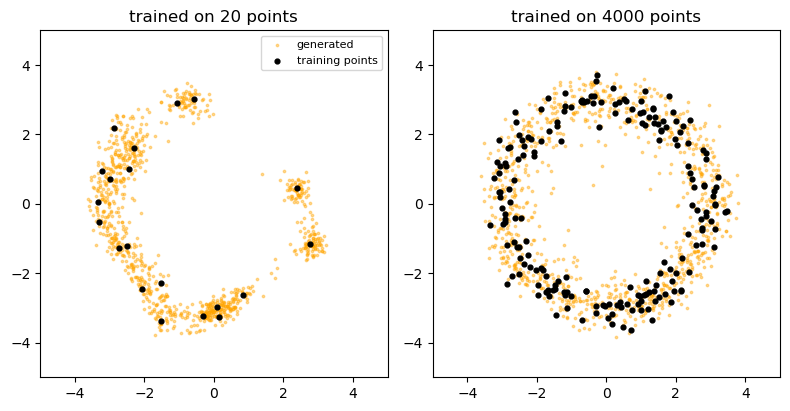

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, (n, (data, gen)) in zip(axes, results.items()):
    ax.scatter(*gen.T, s=3, alpha=0.4, color="orange", label="generated")
    ax.scatter(*data[:200].T, s=12, color="k", label="training points")
    ax.set_title(f"trained on {n} points"); ax.set_aspect("equal"); ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()

**Discuss:**

1. For the 20-point model, compare the distance to the nearest training
   point with what a *perfect* ring sampler would give. If the model were
   memorising, which of the two would be smaller? Is it generating "the
   ring" or "near the 20 examples"?
2. Is memorisation always bad? When would copying a known structure be
   exactly what you want from a structure predictor?
3. The Fromm et al. (2026) antibody benchmark found AlphaFold3 does much
   better when a similar complex was in its training set, but not always.
   How would you design a test set to separate generalisation from
   memorisation? (Day 8.)